# Modelo de Predicción Para Tasa de Mortalidad Estandarizada Rurales vs Urbanas

In [88]:
!pip install pyreadstat


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [89]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score

In [90]:
data_path = 'C:/Users/henry/Documents/jbook/Cacervix/datos/'
data = pd.read_excel(data_path + 'data_final_corregido.xlsx')
# rural_data_cluster = pd.read_excel(data_path + "rural_data_cluster_general_k3.xlsx")
# urbana_data_cluster = pd.read_excel(data_path + "urban_data_cluster_general_k2.xlsx")

In [91]:
data['AREA DE RESIDENCIA'].unique()

array(['Cabecera municipal',
       'Centro poblado (Inspección, corregimiento o caserío)',
       'Rural disperso'], dtype=object)

In [92]:
rural_raw = data[data["AREA DE RESIDENCIA"] != "Cabecera municipal"]
urbana_raw = data[data["AREA DE RESIDENCIA"] == "Cabecera municipal"]

In [93]:
data[['AÑO', 'DEPARTAMENTO', 'Total Mujeres']]

,AÑO,DEPARTAMENTO,Total Mujeres
0,1985,META,192905
1,1985,BOYACÁ,546762
2,1985,META,192905
3,1985,HUILA,345484
4,1985,HUILA,345484
...,...,...,...
58930,2023,RISARALDA,508237
58931,2023,AMAZONAS,41524
58932,2023,META,562262
58933,2023,VALLE DEL CAUCA,2436310


In [94]:
def calcular_tasas(df_zona, nombre_zona):
    resumen = df_zona.groupby(["AÑO", "DEPARTAMENTO DE RESIDENCIA"]).agg(
        DEFUNCIONES=("AÑO", "count"),
        TOTAL_MUJERES=("Total Mujeres", "first")  # tomar solo una por grupo
    ).reset_index()

    resumen["TASA_MORTALIDAD"] = (resumen["DEFUNCIONES"] / resumen["TOTAL_MUJERES"]) * 100000
    resumen["ZONA"] = nombre_zona
    return resumen

In [95]:
tasas_rural = calcular_tasas(rural_raw, "RURAL")
tasas_urbana = calcular_tasas(urbana_raw, "URBANA")
tasas_mortalidad = pd.concat([tasas_rural, tasas_urbana], ignore_index=True)
tasas_unicas = tasas_mortalidad.drop_duplicates(subset=["AÑO", "DEPARTAMENTO DE RESIDENCIA"])


In [96]:
data = data.merge(
    tasas_unicas[["AÑO", "DEPARTAMENTO DE RESIDENCIA", "TASA_MORTALIDAD"]],
    on=["AÑO", "DEPARTAMENTO DE RESIDENCIA"],
    how="left"
)

In [97]:
rural_data = data[data["AREA DE RESIDENCIA"] != "Cabecera municipal"].copy()
urbana_data = data[data["AREA DE RESIDENCIA"] == "Cabecera municipal"].copy()


In [98]:
rural_data.tail(33)

,DEPARTAMENTO,DEPARTAMENTO DE RESIDENCIA,MUNICIPIO,MUNICIPIO DE RESIDENCIA,AÑO,MES,SEX,ESTADO_CIVIL,NIVEL_EDUCACION,GRUPO_ETARIO,...,C_ANT3_DESCRIPCION,C_ANT2_DESCRIPCION,C_ANT1_DESCRIPCION,C_DIR1_DESCRIPCION,AÑO.1,PIB,Total Mujeres,TIENE_COMORBILIDAD,NUM_COMORBILIDADES,TASA_MORTALIDAD
58773,SUCRE,SUCRE,SINCELEJO,SINCELEJO,2023,10,Femenino,Soltero,Primaria,55-59,...,No patología,No patología,No patología,No patología,2023,12705.0,495605,False,0,2.219509
58775,NARIÑO,NARIÑO,PASTO,PASTO,2023,10,Femenino,"Unión Libre, divorciado, otro",Primaria,80-84,...,No patología,No patología,No patología,No patología,2023,23455.0,871313,False,0,2.754464
58780,CÓRDOBA,CÓRDOBA,MONTERÍA,MONTERÍA,2023,10,Femenino,Viudo,Primaria,65-69,...,No patología,No patología,No patología,No patología,2023,28303.0,955208,False,0,5.339151
58782,"BOGOTÁ, D.C.",BOYACÁ,BOGOTÁ D.C.,BOGOTÁ D.C.,2023,2,Femenino,Soltero,Primaria,45-49,...,No patología,No patología,No patología,No patología,2023,395438.0,4120589,False,0,1.975564
58784,NARIÑO,NARIÑO,PASTO,PASTO,2023,11,Femenino,Soltero,Ninguno,75-79,...,No patología,No patología,No patología,No patología,2023,23455.0,871313,False,0,2.754464
58786,ATLÁNTICO,ATLÁNTICO,BARRANQUILLA,BARRANQUILLA,2023,11,Femenino,Soltero,Primaria,50-54,...,No patología,No patología,No patología,No patología,2023,70862.0,1435050,False,0,0.766524
58787,ARAUCA,ARAUCA,ARAUCA,ARAUCA,2023,11,Femenino,Soltero,Secundaria,65-69,...,No patología,No patología,No patología,No patología,2023,8743.0,156828,False,0,3.825847
58790,PUTUMAYO,PUTUMAYO,MOCOA,MOCOA,2023,11,Femenino,Soltero,Superior,55-59,...,No patología,No patología,No patología,No patología,2023,5834.0,191824,False,0,0.688616
58793,RISARALDA,RISARALDA,PEREIRA,PEREIRA,2023,1,Femenino,Viudo,Primaria,55-59,...,No patología,No patología,No patología,No patología,2023,26404.0,508237,False,0,1.574069
58794,SANTANDER,SANTANDER,BUCARAMANGA,BUCARAMANGA,2023,1,Femenino,"Unión Libre, divorciado, otro",Secundaria,45-49,...,No patología,No patología,No patología,No patología,2023,101446.0,1204067,False,0,0.830519


## Modelo de predicción de la tasa de mortalidad estandarizada por zona (Rural vs Urbana)

In [99]:
rural_data.columns.tolist()

['DEPARTAMENTO',
 'DEPARTAMENTO DE RESIDENCIA',
 'MUNICIPIO',
 'MUNICIPIO DE RESIDENCIA',
 'AÑO',
 'MES',
 'SEX',
 'ESTADO_CIVIL',
 'NIVEL_EDUCACION',
 'GRUPO_ETARIO',
 'FECHA',
 'AREA_DEFUN',
 'SITIO_DEFUN',
 'ETNIA',
 'AREA DE RESIDENCIA',
 'SEGURIDAD SOCIAL',
 'C_PAT1_DESCRIPCION',
 'C_ANT3_DESCRIPCION',
 'C_ANT2_DESCRIPCION',
 'C_ANT1_DESCRIPCION',
 'C_DIR1_DESCRIPCION',
 'AÑO.1',
 'PIB',
 'Total Mujeres',
 'TIENE_COMORBILIDAD',
 'NUM_COMORBILIDADES',
 'TASA_MORTALIDAD']

In [120]:
cat_features = ["MUNICIPIO DE RESIDENCIA", "ESTADO_CIVIL", "GRUPO_ETARIO", "ETNIA", "SEGURIDAD SOCIAL", "TIENE_COMORBILIDAD"]
num_features = ["PIB", "Total Mujeres", "NUM_COMORBILIDADES"]

In [ ]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
    ("num", StandardScaler(), num_features)
])


In [ ]:
model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

In [ ]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", model)
])

In [ ]:
def preparar_data_por_zona(df_zona, nombre_zona):
    return df_zona.groupby(["AÑO", "DEPARTAMENTO DE RESIDENCIA"]).agg(
        DEFUNCIONES=("AÑO", "count"),
        PIB=("PIB", "first"),
        **{"Total Mujeres": ("Total Mujeres", "first")},
        NUM_COMORBILIDADES=("NUM_COMORBILIDADES", "mean"),
        ESTADO_CIVIL=("ESTADO_CIVIL", "first"),
        GRUPO_ETARIO=("GRUPO_ETARIO", "first"),
        ETNIA=("ETNIA", "first"),
        **{"SEGURIDAD SOCIAL": ("SEGURIDAD SOCIAL", "first")},
        TIENE_COMORBILIDAD=("TIENE_COMORBILIDAD", "first")
    ).reset_index()

In [ ]:
def evaluar_expanding_window(df, zona):
    df = df.sort_values("AÑO").copy()
    features = cat_features + num_features
    years = sorted(df["AÑO"].unique())

    print(f"\n Resultados para zona: {zona.upper()}")
    for i in range(6, len(years)):
        años_train = years[:i]
        año_val = years[i]

        df_train = df[df["AÑO"].isin(años_train)]
        df_val = df[df["AÑO"] == año_val]

        X_train = df_train[cat_features + num_features]
        y_train = df_train["DEFUNCIONES"]

        X_val = df_val[cat_features + num_features]
        y_val = df_val["DEFUNCIONES"]

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_val)

        mae = mean_absolute_error(y_val, y_pred)
        r2 = r2_score(y_val, y_pred)

        print(f"Entrena {años_train[0]}–{años_train[-1]} → Valida {año_val} | MAE: {mae:.2f}, R²: {r2:.4f}")


In [ ]:
def predecir_defunciones_futuras(df, zona):
    df = df.sort_values("AÑO").copy()
    df_2023 = df[df["AÑO"] == 2023].copy()
    anios_futuros = list(range(2024, 2031))

    # Proyección simple (ajústala según contexto)
    crecimiento_pib = 0.03
    crecimiento_poblacional = 0.01
    crecimiento_comorbilidades = 0.00  # constante

    registros_futuros = []

    for anio in anios_futuros:
        factor_anios = anio - 2023

        df_anio = df_2023.copy()
        df_anio["AÑO"] = anio
        df_anio["PIB"] = df_anio["PIB"] * (1 + crecimiento_pib) ** factor_anios
        df_anio["Total Mujeres"] = df_anio["Total Mujeres"] * (1 + crecimiento_poblacional) ** factor_anios
        df_anio["NUM_COMORBILIDADES"] = df_anio["NUM_COMORBILIDADES"] * (1 + crecimiento_comorbilidades) ** factor_anios

        registros_futuros.append(df_anio)

    df_futuro = pd.concat(registros_futuros, ignore_index=True)

    # Entrenamiento completo con los datos históricos
    X_all = df[cat_features + num_features]
    y_all = df["DEFUNCIONES"]
    pipeline.fit(X_all, y_all)

    # Predicción
    X_futuro = df_futuro[cat_features + num_features]
    df_futuro["DEFUNCIONES_PREDICHAS"] = pipeline.predict(X_futuro)
    df_futuro["ZONA"] = zona

    resumen = df_futuro.groupby("AÑO")["DEFUNCIONES_PREDICHAS"].sum().reset_index()
    print(f"\n Predicción total de defunciones (zona {zona.upper()}):")
    print(resumen)

    return df_futuro

In [ ]:
rural_raw = data[data["AREA DE RESIDENCIA"] != "Cabecera municipal"]
urbana_raw = data[data["AREA DE RESIDENCIA"] == "Cabecera municipal"]

In [ ]:
rural_data_agg = preparar_data_por_zona(rural_raw, "rural")
urbana_data_agg = preparar_data_por_zona(urbana_raw, "urbana")

In [186]:
evaluar_expanding_window(rural_data_agg, "rural") 


 Resultados para zona: RURAL
Entrena 1985–1990 → Valida 1991 | MAE: 1.97, R²: 0.5118
Entrena 1985–1991 → Valida 1992 | MAE: 2.96, R²: 0.5218
Entrena 1985–1992 → Valida 1993 | MAE: 3.37, R²: 0.5847
Entrena 1985–1993 → Valida 1994 | MAE: 3.64, R²: 0.6553
Entrena 1985–1994 → Valida 1995 | MAE: 2.60, R²: 0.7661
Entrena 1985–1995 → Valida 1996 | MAE: 5.75, R²: 0.2079
Entrena 1985–1996 → Valida 1997 | MAE: 5.06, R²: 0.6424
Entrena 1985–1997 → Valida 1998 | MAE: 4.49, R²: 0.5715
Entrena 1985–1998 → Valida 1999 | MAE: 5.73, R²: 0.4690
Entrena 1985–1999 → Valida 2000 | MAE: 3.76, R²: 0.8087
Entrena 1985–2000 → Valida 2001 | MAE: 3.45, R²: 0.8150
Entrena 1985–2001 → Valida 2002 | MAE: 4.06, R²: 0.7462
Entrena 1985–2002 → Valida 2003 | MAE: 4.15, R²: 0.7421
Entrena 1985–2003 → Valida 2004 | MAE: 3.47, R²: 0.8365
Entrena 1985–2004 → Valida 2005 | MAE: 4.08, R²: 0.6486
Entrena 1985–2005 → Valida 2006 | MAE: 2.66, R²: 0.9046
Entrena 1985–2006 → Valida 2007 | MAE: 2.80, R²: 0.7930
Entrena 1985–2007 

In [187]:
evaluar_expanding_window(urbana_data_agg, "urbana")



 Resultados para zona: URBANA
Entrena 1985–1990 → Valida 1991 | MAE: 12.80, R²: 0.8315
Entrena 1985–1991 → Valida 1992 | MAE: 9.19, R²: 0.9315
Entrena 1985–1992 → Valida 1993 | MAE: 7.14, R²: 0.9607
Entrena 1985–1993 → Valida 1994 | MAE: 6.58, R²: 0.9597
Entrena 1985–1994 → Valida 1995 | MAE: 9.10, R²: 0.9370
Entrena 1985–1995 → Valida 1996 | MAE: 11.41, R²: 0.8868
Entrena 1985–1996 → Valida 1997 | MAE: 6.01, R²: 0.9720
Entrena 1985–1997 → Valida 1998 | MAE: 6.41, R²: 0.9745
Entrena 1985–1998 → Valida 1999 | MAE: 9.29, R²: 0.9226
Entrena 1985–1999 → Valida 2000 | MAE: 7.00, R²: 0.9661
Entrena 1985–2000 → Valida 2001 | MAE: 8.34, R²: 0.9248
Entrena 1985–2001 → Valida 2002 | MAE: 11.70, R²: 0.9179
Entrena 1985–2002 → Valida 2003 | MAE: 13.41, R²: 0.8716
Entrena 1985–2003 → Valida 2004 | MAE: 7.52, R²: 0.9556
Entrena 1985–2004 → Valida 2005 | MAE: 9.04, R²: 0.9479
Entrena 1985–2005 → Valida 2006 | MAE: 6.47, R²: 0.9576
Entrena 1985–2006 → Valida 2007 | MAE: 6.46, R²: 0.9744
Entrena 1985–

In [188]:
# Predicciones 2024–2030
rural_pred = predecir_defunciones_futuras(rural_data_agg, "rural")
urbana_pred = predecir_defunciones_futuras(urbana_data_agg, "urbana")



 Predicción total de defunciones (zona RURAL):
    AÑO  DEFUNCIONES_PREDICHAS
0  2024             342.580505
1  2025             342.276306
2  2026             343.873291
3  2027             342.509094
4  2028             342.284821
5  2029             342.502106
6  2030             345.247955

 Predicción total de defunciones (zona URBANA):
    AÑO  DEFUNCIONES_PREDICHAS
0  2024            1541.489746
1  2025            1536.023682
2  2026            1547.362915
3  2027            1548.169556
4  2028            1556.561768
5  2029            1559.287476
6  2030            1564.508667


In [189]:
# Combinar predicciones
predicciones_completas = pd.concat([rural_pred, urbana_pred], ignore_index=True)

In [ ]:
evolucion_defunciones = predicciones_completas.groupby(["AÑO", "ZONA"])["DEFUNCIONES_PREDICHAS"].sum().reset_index()

# Separar por zona
rural = evolucion_defunciones[evolucion_defunciones["ZONA"] == "rural"]
urbana = evolucion_defunciones[evolucion_defunciones["ZONA"] == "urbana"]

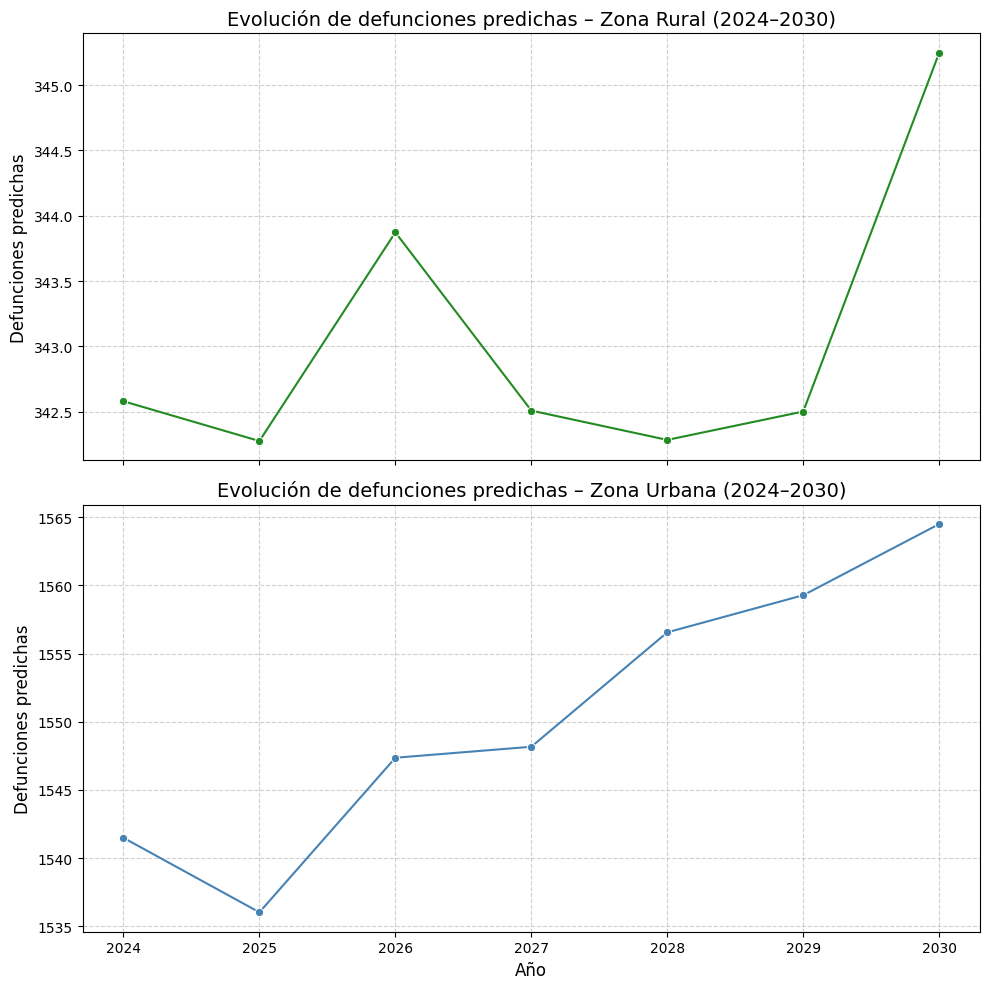

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Gráfico para zona rural
sns.lineplot(
    data=rural,
    x="AÑO",
    y="DEFUNCIONES_PREDICHAS",
    marker="o",
    color="forestgreen",
    ax=axes[0]
)
axes[0].set_title("Evolución de defunciones predichas – Zona Rural (2024–2030)", fontsize=14)
axes[0].set_ylabel("Defunciones predichas", fontsize=12)
axes[0].grid(True, linestyle="--", alpha=0.6)

# Gráfico para zona urbana
sns.lineplot(
    data=urbana,
    x="AÑO",
    y="DEFUNCIONES_PREDICHAS",
    marker="o",
    color="steelblue",
    ax=axes[1]
)
axes[1].set_title("Evolución de defunciones predichas – Zona Urbana (2024–2030)", fontsize=14)
axes[1].set_xlabel("Año", fontsize=12)
axes[1].set_ylabel("Defunciones predichas", fontsize=12)
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

